### Learn to predict the bounding box



This notebook requires that you have downloaded the Thoracic organ at risk component of the struct seg dataset and placed it in a folder with the relative location of './data/ThoracicOAR'.

The data is available from https://structseg2019.grand-challenge.org/Dataset/

Let's take a look at the data. Start by loading an image slice.


In [1]:
import os
import numpy as np
import nibabel as nib
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt


def show_first_image_and_labels(im_dir_name = '1'):
    im_data_dir = os.path.join(DATA_DIR, im_dir_name)
    assert os.path.isdir(im_data_dir), f'{im_data_dir} required. Did you download struct seg?'
    
    # get data and heart labels for a patch with the heart in it
    image_data, heart_labels = load_im_and_heart(im_data_dir)

    print('im shape', image_data.shape)
    print('heart shape', heart_labels.shape)
    # lets show a slice with some labels.

    total_heart = np.sum(heart_labels).item()
    print('unique heart= ', np.unique(heart_labels))
    total_scan = np.prod(heart_labels.shape)
    percent_heart = (total_heart / total_scan) * 100
    print('actual', total_heart, 'out of total', total_scan, 'giving percent', percent_heart) 
    
    # Which slices contain heart?
    with_heart = [y for y in range(heart_labels.shape[0]) if np.any(heart_labels[y])]
    central_slice_idx = with_heart[len(with_heart)//2]
    central_slice_im = image_data[central_slice_idx]
    central_slice_labels = heart_labels[central_slice_idx]
                  
    im_for_show = np.hstack((central_slice_im, central_slice_labels*np.max(central_slice_im)))
    plt.figure(figsize=(12,12))
    imshow(im_for_show, cmap='gray')

#show_first_image_and_labels()
    

"The model was implemented using the TensorFlow framework. To reduce the effects of unbalanced voxels of different organs, the weighted cross‐entropy loss was used. The relative weights for background and five organs were: background: 1.0, spinal cord: 2.0, right lung: 1.0, left lung: 1.0, heart: 1.0, and esophagus: 2.0."[0]

"During testing, isolated voxels labeled as pertaining to a specific organ which are not connected to the majority of the voxels belonging to that organ are regarded as false positives during postprocessing. Therefore, to remove those, for each organ, the number of voxels of each connected region was calculated and the voxels belonging to largest region were labeled as foreground while voxels from the other connected regions were relabeled as background."[0]

"inclusion of background voxels close to the boundary can provide additional information for the segmentation network to learn. Therefore, during cropping, after the exact range of the organ is obtained, a bounding box slightly larger than the range will be used for cropping. Specifically, the following equations were used to determine the starting and ending coordinates:"[0]

$i_{start} = Max(0, i_{min} - \alpha * (i_{max} - i_{min}))$

$i_{end} = Min(D_{i}, i_{max} - \beta * (i_{max} - i_{min}))$

"Where $i$ is the image dimension. $i_{min}$ is the minimum foreground voxel coordinates in the dimension $i$. 
$i_{max}$ is maximum foreground voxel coordinate in the dimension $i$.
And $\alpha$"[0]


"$\alpha$ and $\beta$ were randomly generated between 0.1 and 0.7 using a uniform distribution for all three axes and during every iteration as a data augmentation mechanism to accommodate for inaccuracy in boundary determination when the ground‐truth label map is unavailable."[0]

I won't do this. I will just use a fixed context region e.g 0.5x bounding box or whatever.




To summarize: I think it's fine for me to simply take a lower resolution version of the image, then restrict to single largest region of predicted foreground pixels and then add N pixels in each dimension before cropping (i.e 72).



In [2]:
# In the paper they resize every image to 72, 208, 208 for the localization network.

# let's see how big the struct seg images are before resizing.

def get_image_depths():
    im_dir_names = os.listdir(DATA_DIR)
    depths = []
    for im_name in im_dir_names:
        im_data_dir = os.path.join(DATA_DIR, im_name)
        # get data and heart labels for a patch with the heart in it
        image_data, heart_labels = load_im_and_heart(im_data_dir)
        depths.append(image_data.shape[0])
        print(image_data.shape,end=',')

    return depths


# Lets use the mean depth and then resize all the images to this.
#depths = get_image_depths()
#mean_im_depth = round(np.mean(depths))
#print('depths range from ', min(depths), 'to', max(depths), 'and the mean is', mean_im_depth)


The Raw image sizes range from (80, 512,512) to (127, 512,512).
If we were to 50% we would get (40,256,256) to (64,256,256).


I'm not sure if this would actually fit in the GPU memory of the network. Anyway let's just train to predict a heart on these half size images and see what happens.



In [3]:
# first lets prepare the data to be half size so we don't need to run this every time.
HALF_DATA_DIR = os.path.join('data', 'ThoracicOAR_half')
EIGHTH_DATA_DIR = os.path.join('data', 'ThoracicOAR_eighth')
from data_prep import create_smaller_size_dataset
create_smaller_size_dataset()
#assert sorted(os.listdir(DATA_DIR)) == sorted(os.listdir(HALF_DATA_DIR))

From the 50 Struct seg images that are available to download, we sampled 34,8 and 8 at random to be in the train set, validation and test set respectively

In [4]:
import random
random.seed(42)

def create_train_val_split():
    all_fnames = os.listdir(HALF_DATA_DIR)
    # 34 in the train set and 8 in the validation set and 8 in the test set.
    random.shuffle(sorted(all_fnames))
    train_set = all_fnames[:34]
    val_set = all_fnames[34:42]
    test_set = all_fnames[42:]
    assert len(train_set) == 34
    assert len(val_set) == 8
    assert len(test_set) == 8
    return train_set, val_set, test_set
    
train, val, test = create_train_val_split()

Then we created a PyTorch dataset to facilitate training a UNet model.

In [5]:
from skimage.io import imread
from torch.utils.data import Dataset, DataLoader

class ImageDataset(Dataset):
    
    def __init__(self, im_names, parent_folder_path):
        self.im_names = im_names
        self.parent_dir = parent_folder_path

    def __len__(self):
        return len(self.im_names)

    def __getitem__(self, idx):
        im_name = self.im_names[idx]
        im, heart_labels = load_im_and_heart(os.path.join(self.parent_dir, im_name),
                                             filter_labels=False)
        # add a channel dimension at the start, torch needs it
        im = np.expand_dims(im, axis=0).astype(np.float32)
        heart_labels = heart_labels.astype(np.int16)
        return im, heart_labels
    

def create_datasets(train, val, test):
    train_dataset = ImageDataset(train, HALF_DATA_DIR)
    val_dataset = ImageDataset(val, HALF_DATA_DIR)
    test_dataset = ImageDataset(test, HALF_DATA_DIR)
    return train_dataset, val_dataset, test_dataset

train_ds, val_ds, test_ds = create_datasets(train, val, test)
    

Initialise a network and then train it to predict the labels

In [10]:
import torch.nn.functional as F
import torch
from unet3d import UNet3D
from loss import combined_loss
import time
from metrics import get_metrics_from_arrays, get_metrics_str, get_metrics, get_metric_csv_row

def train_network(epochs):
    print('1')
    dataloader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=12)
    cnn = UNet3D(im_channels=1, out_channels=2).cuda()
    optimizer = torch.optim.SGD(cnn.parameters(), lr=0.01, momentum=0.9, nesterov=True)
    loss_fn = combined_loss
    train_log = open(f'train_metrics_lr_0.01_combined_{time.time()}.csv', 'w+')
    metric_list = []
    for i in range(epochs):
        print('start epoch', i)
        tps = []
        tns = []
        fps = []
        fns = []
        for step, (image_batch, labels_batch) in enumerate(dataloader):
            print('step', step, end='\r')
            optimizer.zero_grad()
            outputs = cnn(image_batch.cuda())
            labels_batch  = labels_batch.cuda().long()
            loss = loss_fn(outputs, labels_batch)
            loss.backward()
            optimizer.step()
            preds_int = torch.argmax(outputs, 1)
            foregrounds_int = labels_batch
            tps.append(torch.sum((foregrounds_int == 1) * (preds_int == 1)).cpu().numpy())
            tns.append(torch.sum((foregrounds_int == 0) * (preds_int == 0)).cpu().numpy())
            fps.append(torch.sum((foregrounds_int == 0) * (preds_int == 1)).cpu().numpy())
            fns.append(torch.sum((foregrounds_int == 1) * (preds_int == 0)).cpu().numpy())
        m = get_metrics(np.sum(tps), np.sum(fps), np.sum(tns), np.sum(fns))
        print('epoch', i, get_metrics_str(m))
        print(f'{time.time()},{get_metric_csv_row(m)}', file=train_log)
        metric_list.append(m)
    return metric_list

metric_list = train_network(15)

1
start epoch 0
epoch 0  accuracy 0.9766 tp 3.377e+04 fp 2.105e+06 tn 1.044e+08 fn 3.967e+05 precision 0.01579 recall 0.07845 dice 0.02629 true_mean 0.004025 true 4.305e+05 pred 2.139e+06
start epoch 1
epoch 1  accuracy 0.995 tp 2.914e+04 fp 1.368e+05 tn 1.064e+08 fn 4.013e+05 precision 0.1756 recall 0.06769 dice 0.09772 true_mean 0.004025 true 4.305e+05 pred 1.659e+05
start epoch 2
epoch 2  accuracy 0.9928 tp 4.96e+04 fp 3.903e+05 tn 1.061e+08 fn 3.809e+05 precision 0.1128 recall 0.1152 dice 0.114 true_mean 0.004025 true 4.305e+05 pred 4.399e+05
start epoch 3
epoch 3  accuracy 0.9957 tp 2.496e+04 fp 5.772e+04 tn 1.065e+08 fn 4.055e+05 precision 0.3019 recall 0.05798 dice 0.09728 true_mean 0.004025 true 4.305e+05 pred 8.268e+04
start epoch 4
epoch 4  accuracy 0.996 tp 0 fp 580 tn 1.065e+08 fn 4.305e+05 precision nan recall nan dice nan true_mean 0.004025 true 4.305e+05 pred 580
start epoch 5
epoch 5  accuracy 0.996 tp 0 fp 375 tn 1.065e+08 fn 4.305e+05 precision nan recall nan dice nan

[0.009863798251133636, 0.02368014256687885, 0.6352471670988369, 0.589422924345549, 0.7465391008641146, 0.7936206638178839, 0.8081555848775169, 0.8136633764025213, 0.8361581660782957, 0.8433383496683301, 0.8699032986185351, 0.8774584277350387, 0.8868695984172712, 0.8871116147414901, 0.8970838379262847]


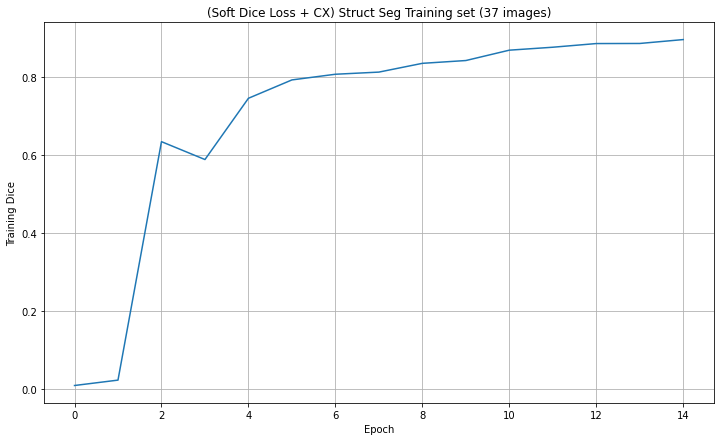

In [8]:
dices = [m['dice'] for m in metric_list]
print(dices)
plt.figure(figsize=(12,7))
plt.ylabel('Training Dice')
plt.xlabel('Epoch')
plt.title('(Soft Dice Loss + CX) Struct Seg Training set (37 images)')
plt.grid()
plt.plot(dices)


### Now let's try to reproduce on a different dataset.
https://wiki.cancerimagingarchive.net/display/Public/Lung+CT+Segmentation+Challenge+2017